# Primary Productivity Unbiased Relative Difference Analysis  
## Unbiased relative difference analysis of the interim (VIIRS-NOAA20) and legacy (MODIS-AQUA) products
> History | Updated Dec 2024

## Objectives
Calculate the mean unbiased relative difference (&psi;<sup>netPP</sup>) of the interim VIIRS netPP (netPP<sub>VIIRS</sub>) and legacy MODIS netPP (netPP<sub>MODIS</sub>) products for each month from the timeseries shared between the two sensors. 

We are using this statistic to track the similarities in netPP values between interim VIIRS and legacy MODIS datasets to provide validation that the interim netPP products can be reliably used for continuity in long-term productivity analyses.

The result will be a **60-month (5-year)** mean monthly timeseries of &psi;<sup>netPP</sup>.

* &psi;<sub>netPP</sub> was calculated as the difference between VIIRS and MODIS netPP values divided by the mean of VIIRS and MODIS.

* Normalizing by the mean of the two values avoids arbitrarily selecting one product as reference.     

## Satellite Datasets:  
### Unbiased Relative Difference
The unbiased relative difference (&psi;<sup>netPP</sup>) is calculated, for each pixel as follows:

$
\Large\psi^{netPP} = \frac{netPP_{VIIRS} - netPP_{MODIS}}{(netPP_{VIIRS} + netPP_{MODIS}) \div 2}\
$  

Where:
* The difference between VIIRS-based netPP (netPP<sub>VIIRS</sub>) and MODIS-based (netPP<sub>MODIS</sub>) netPP values for that pixel is divided by the mean of netPP<sub>VIIRS</sub> and netPP<sub>MODIS</sub>. 


### Datasets Overview

We will be creating the pixel-by-pixel unbiased relative difference (&psi;<sup>netPP</sup>) for the globe for each monthy at a 9km resolution across two datasets:

1. **Primary Productivity, MODIS-AQUA, Science Quality, Global, 9km, 2013-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/productivity_modis_aqua_monthly.graph

2. **Primary Productivity, VIIRS-NOAA20, Science Quality, Global, 9km, 2018-2022 (Monthly Composite)**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/productivity_viirs_noaa20_monthly.graph


## Tutorial for this notebook

By following this tutorial, users will:
* Calculate (&psi;<sup>netPP</sup>) between MODIS-AQUA and VIIRS-NOAA20 to track the level of agreement on a pixel-by-pixel basis across global monthly composites.

* Process monthly NetPP data to create and plot the timeseries and spatial variability between the two datasets.

### Resource requirements
-   **Jupyter Notebook** 

-   **Python 3** with the modules included within the *Import packages* section below

-   **Internet connection**  

## Import packages

In [1]:
import os
import subprocess
from datetime import timezone, datetime
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dateutil import rrule
from dateutil.parser import parse
import xarray as xr
from netCDF4 import Dataset
import pandas as pd

## Create global variables
Global variables are used to set up the file structure, directory paths, and template files required for processing psi.

In [2]:
ROOT_DIR = "/Users/madisonrichardson/netpp"
VIIRS_DIR_T = os.path.join(ROOT_DIR, "data/{}/monthly/netpp")
MODIS_DIR = os.path.join(ROOT_DIR, "data/modis/monthly_netpp")
WORK_DIR = os.path.join(ROOT_DIR, "work")
BIN_DIR = os.path.join(ROOT_DIR, "bin")
RES_DIR = os.path.join(ROOT_DIR, "resources")
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/matrix/psi")
CDL_IN_FILE = "psi_nasa_9k_mr_dr.cdl"
TEMP_OUT_FILE = "tempoutfile.nc"
NCO_DIR = "/Users/madisonrichardson/miniforge3/bin/"

## Create some useful functions
### Function to generate a NetCDF file from a CDL file
The function creates a NetCDF file from a CDL template using 'ncgen'.

In [3]:
def make_ncfile_from_cdl_dr(path_cdl, path_ncfile, nco_path):
    """
    Make a NetCDF file from a CDL (Common Data Language) file
    template using the ncgen tool.

    Args:
        path_cdl (str): The path to the input CDL file that defines
                        the structure of the NetCDF file.
        path_ncfile (str): The path to the output NetCDF file that
                            will be created by ncgen.
        nco_path (str): The path to the directory containing the
                        NCO (NetCDF Operators) tools such as ncgen
                        to make the NetCDF file from the CDL file.
    """
    myCmd = " ".join(
        [os.path.join(nco_path, "ncgen"), "-o", path_ncfile, path_cdl]
    )

    print(
        "Generated NetCDF template", subprocess.call(myCmd, shell=True)
    )  # prints zero if myCmd is success

## Function to find the unbiased relative difference (psi) between NOAA20 and MODIS NetPP datasets
The function computes the unbiased relative difference (psi) between two datasets.

In [4]:
# Function to calculate unbiased relative difference (psi) using NetPP
def calculate_psi_dr(minuend_data, subtrahend_data):
    """
    Calculate the unbiased relative difference (psi) between the two
    datasets.

    Nerd Notation
    minuend is math-speak for the value substracted from.

    subtrahend is math-speak for the value that is substracted.

    Args:
        minuend_data (ma.MaskedArray): The dataset where values will be
                                    subtracted.
        subtrahend_data (ma.MaskedArray): The dataset that will be subtracted
                                        from 'minuend_data'.

    Returns:
        ma.MaskedArray: The array of unbiased relative difference (psi) values
                        where missing data remains masked.
    """

    # Calculate the average of input datasets
    avg = ma.divide(ma.add(minuend_data, subtrahend_data), 2)

    # Calculate unbiased relative difference (psi)
    psi_values = ma.divide(ma.subtract(minuend_data, subtrahend_data), avg)

    return psi_values

### Function to populate a NetCDF file with a 3D matrix of the psi values
The function populates a single NetCDF file with psi values for all years and months.

In [5]:
def get_nc_var_data_dr(file1_path, my_var):
    """
    Extract data from specified variable in a NetCDF file.

    Args:
        file1_path (str): The full path to the NetCDF file from
                            where the data is extracted.
        my_var (str): The name of the variable in the NetCDF file
                        to extract (e.g., 'productivity).

    Returns:
        netpp_file1 (numpy.ndarray): A 2D array (latitude, longitude) containing
        the data for the first time step of the specified variable.
    """

    file1 = Dataset(file1_path, "r")

    # Extract NetPP data
    netpp_file1 = file1.variables[my_var][0, :, :]

    # Close the VIIRS and MODIS files
    file1.close()

    return netpp_file1

## Initialize parameters

Set the input parameters for the analysis, including:

- Start and end year/month for processing data

- Sensor type (either 'noaa20' or 'noaa21')

- Overwrite flag to determine whether to overwrite exisiting files



In [6]:
# Set the parameters for the code
start_yr_mo = "2013-01"
end_yr_mo = "2022-12"
sensor = "snpp"  # Either snpp or noaa20
overwrite = True  # Change to True if you want to overwrite existing NetCDF file

# Current timestamp for metadata
now = datetime.now()

# Dictionary for added metadata
end_year = {"snpp": "2013"}

# Parse the start and end dates from the year-month strings
start_date = parse(start_yr_mo)
end_date = parse(end_yr_mo)

# Adjust the start and end dates to be centered on the 16th of the month
start_date = start_date.replace(day=16)
end_date = end_date.replace(day=16)

# Print the parsed and adjusted start and end dates for verification
print(start_date, end_date)

2013-01-16 00:00:00 2022-12-16 00:00:00


## Set up directories
Create necessary directories for storing data, intermediate files, and results. The directories will be created dynamically if they do not already exist.

In [7]:
# Create dynamic directories and verify
VIIRS_DIR = VIIRS_DIR_T.format(sensor)
NC_OUT_DIR = NC_OUT_DIR_T.format(sensor)

# Create a list of all required directories for the workflow
DIR_LIST = [
    ROOT_DIR,
    WORK_DIR,
    RES_DIR,
    VIIRS_DIR,
    MODIS_DIR,
    NC_OUT_DIR,
    NCO_DIR,
]

# Iterate through the directory list and create each directory exists, create if not
for dr in DIR_LIST:
    os.makedirs(dr, exist_ok=True)

# Print the number of directories validated
print(len(DIR_LIST), "directories validated")

7 directories validated


## Define time range and output file

In [8]:
# Define time range and output file
yr_mo_to_bin = rrule.rrule(rrule.MONTHLY, dtstart=start_date, until=end_date)
yr_mo_to_bin = list(yr_mo_to_bin)

# Define the final output file path
nc_filename = f"netpp_psi_{sensor}_modis.nc"
nc_file_path = os.path.join(NC_OUT_DIR, nc_filename)

# Add logic to not overwrite existing files
if os.path.isfile(nc_file_path):
    if not overwrite:
        print(f"{nc_filename} already exists for {sensor}")
    else:
        print(f"Overwriting {nc_filename} for {sensor}")

## Generate initial NetCDF template
Generate a netCDF file using a CDL template. This file will store the 3D matrix of psi values.

In [9]:
# Generate the initial NetCDF template from CDL for all years
make_ncfile_from_cdl_dr(
    os.path.join(RES_DIR, CDL_IN_FILE),
    os.path.join(WORK_DIR, nc_file_path),
    NCO_DIR,
)

Generated NetCDF template 0


## Open NetCDF file and process data
Iterate through each time step, calculate the unbiased relative difference (psi), and populate the NetCDF file.

In [10]:
# Name of variable in NetPP file
netpp_var = "productivity"

# Open the NetCDF file in append mode to add data
nc_file = Dataset(nc_file_path, "a", format="NETCDF4")

# Initialize the time index for adding data to the NetCDF file
time_index = 0

# Loop through each month in the defined time range
for dt in yr_mo_to_bin:
    file_date = "{0:%Y%m}".format(dt)
    year = "{0:%Y}".format(dt)
    print("Processing", file_date)

    # Construct the file paths for the VIIRS and MODIS NetPP data files
    viirs_file_path = os.path.join(
        VIIRS_DIR, f"productivity_month_nasa_{file_date}_9km.nc"
    )
    modis_file_path = os.path.join(
        MODIS_DIR, f"productivity_month_modis_{file_date}_9km.nc"
    )

    # Check if both VIIRS and MODIS files exist
    if not os.path.exists(viirs_file_path) or not os.path.exists(
        modis_file_path
    ):
        print(f"Files for {file_date} are missing! Skipping...")
        continue

    # Extract NetPP data from the VIIRS and MODIS files
    viirs_npp = get_nc_var_data_dr(viirs_file_path, netpp_var)
    modis_npp = get_nc_var_data_dr(modis_file_path, netpp_var)

    # Check if the data dimensions match between the two datasets
    if viirs_npp.shape != modis_npp.shape:
        err_msg = (
            "Dimension mismatch. Viirs shape: "
            f"{viirs_npp.shape}, Legacy shape: "
            f"{modis_npp.shape}"
        )
        raise ValueError(err_msg)
        print("Skipping...", file_date)
        continue

    # Calculate the unbiased relative difference (psi) between the two datasets
    psi = calculate_psi_dr(viirs_npp, modis_npp)
    print("psi calculated for", file_date)

    # Convert the date to UTC and add the timestamp to the NetCDF file
    dt = dt.replace(tzinfo=timezone.utc)
    nc_file["time"][time_index] = dt.timestamp()

    # Add the calculated psi values to the NetCDF file
    nc_file["psi"][time_index, :, :] = psi[:, :]
    nc_file.sync()
    print(file_date, "data saved to nc file")

    # Modify the metadata
    nc_file.date_created = now.isoformat("T", "seconds")
    nc_file.id = f"netpp_psi_{sensor}_modis"
    nc_file.title = ", ".join(
        [
            "Unbiased Relative Difference of Net Primary Productivity",
            f"VIIRS-{sensor.upper()} vs MODIS-Aqua ",
            "9km",
            "Monthly",
            "2018-2022",
            "Global",
        ]
    )
    nc_file.institution = "NOAA/NESDIS/STAR/CoastWatch/WestCoast"
    nc_file.creator_name = "NOAA CoastWatch West Coast Node"
    nc_file.creator_url = "https://coastwatch.pfeg.noaa.gov/"
    nc_file.instrument = "VIIRS, MODIS"
    nc_file.acknowledgement = "The project was supported by funding from the Portfolio Management Branch of NESDIS and NOAA CoastWatch."
    nc_file.contributors = "Dale Robinson, Isaac Shroeder, Ryan Vandermeulen, Jonathan Sherman, Jesse Espinoza, & Madison Richardson"

    # Increment the time index for the next iteration
    time_index += 1

# Close the NetCDF file after all data is written
nc_file.close()

Processing 201301
psi calculated for 201301
201301 data saved to nc file


/var/folders/81/qj7mv_yn7p98wpb9n0np6q8c0000gn/T/ipykernel_22624/4290850918.py:55: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  nc_file["psi"][time_index, :, :] = psi[:, :]


Processing 201302
psi calculated for 201302
201302 data saved to nc file
Processing 201303
psi calculated for 201303
201303 data saved to nc file
Processing 201304
psi calculated for 201304
201304 data saved to nc file
Processing 201305
psi calculated for 201305
201305 data saved to nc file
Processing 201306
psi calculated for 201306
201306 data saved to nc file
Processing 201307
psi calculated for 201307
201307 data saved to nc file
Processing 201308
psi calculated for 201308
201308 data saved to nc file
Processing 201309
psi calculated for 201309
201309 data saved to nc file
Processing 201310
psi calculated for 201310
201310 data saved to nc file
Processing 201311
psi calculated for 201311
201311 data saved to nc file
Processing 201312
psi calculated for 201312
201312 data saved to nc file
Processing 201401
psi calculated for 201401
201401 data saved to nc file
Processing 201402
psi calculated for 201402
201402 data saved to nc file
Processing 201403
psi calculated for 201403
201403 

## Compress and archive NetCDF file

In [11]:
# Define the path for the compressed NetCDF file
compressed_nc_file_path = os.path.join(NC_OUT_DIR, "compressed_" + nc_filename)

# Compress file with nccopy
compressed_cmd = " ".join(
    ["nccopy", "-d4", nc_file_path, compressed_nc_file_path]
)

# Execute the compression command and log the result
print("Compress ofile", subprocess.call(compressed_cmd, shell=True))

# Construct the command to move the compressed file back to the original file path
archive_cmd = " ".join(["mv", compressed_nc_file_path, nc_file_path])

# Execute the archive command and log the result
print("Archive ofile", subprocess.call(archive_cmd, shell=True))

# Log a message indicating the final location of the archived NetCDF file
print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")

Compress ofile 0
Archive ofile 0
NetCDF file 'netpp_psi_snpp_modis.nc' archived at /Users/madisonrichardson/netpp/data/snpp/matrix/psi/netpp_psi_snpp_modis.nc


## Extract NetPP data from ERDDAP
### Function to make an Xarray dataset connection to an ERDDAP dataset

In [12]:
def xr_open_ds(e_id, e_source="http://localhost:8080/erddap", dap="griddap"):
    """Open a remote ERDDAP dataset.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to
            'http://localhost:8080/erddap'. You can change to any ERDDAP

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

In [13]:
erddap_id = "netpp_psi_noaa20_modis"
erddap_url = "http://localhost:8080/erddap"

ds = xr_open_ds(erddap_id, erddap_url)
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 60, latitude: 2160, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 480B 2018-01-16 2018-02-16 ... 2022-12-16
  * latitude   (latitude) float64 17kB 89.96 89.88 89.79 ... -89.88 -89.96
  * longitude  (longitude) float64 35kB -180.0 -179.9 -179.8 ... 179.9 180.0
Data variables:
    psi        (time, latitude, longitude) float32 2GB ...
Attributes: (12/37)
    acknowledgement:           The project was supported by funding from the ...
    cdm_data_type:             Grid
    contributors:              Dale Robinson, Isaac Shroeder, Ryan Vandermeul...
    Conventions:               COARDS, CF-1.10, ACDD-1.3
    creator_email:             erd.data@noaa.gov
    creator_name:              NOAA CoastWatch West Coast Node
    ...                        ...
    summary:                   The unbiased relative difference (Psi) between...
    time_coverage_end:         2022-12-16T00:00:00Z
    time_coverage_resolution:  PDM
    time_coverage_start:       2018-01-16T00:00:00Z
    title:                     Unbiased Relative Difference of Net Primary Pr...
    Westernmost_Easting:       -179.9583

## Calculate the monthly mean for each month to create a timeseries
For each month of the timeseries (60-months) generate the mean &psi;<sup>netPP</sup>.  
 
$
\Large\bar{\psi}^{netPP}  = \frac{1}{N}\ \sum_{i=1}^{N} \psi^{netPP}_{i}
$   

 * Where for each month N is the the number of pixels (<i>i</i>) within a month's grid with &psi;<sup>netPP</sup> values . 

Also, calculate the minimum and maximum for data verification.

In [14]:
# Pull the psi variable from the ERDDAP dataset
da = ds.psi

# Calculate the mean, maximum, and minimum psi values
# across latitude and longitude dimensions
psi_mean3 = da.mean(dim=["latitude", "longitude"], skipna=True)
psi_max = da.max(dim=["latitude", "longitude"], skipna=True)
psi_min = da.min(dim=["latitude", "longitude"], skipna=True)

# Convert the time values from the dataset to pandas
# datetime objects for readability
my_date = pd.to_datetime(da.time.values)

# Iterate over each time step and print the calculated psi statistics
for i in range(0, my_date.size):
    print("For", "{0:%B %Y}".format(my_date[i]))
    print(
        f"Mean psi {psi_mean3[0]:.2f}",
        f"Min psi {psi_min[0]:.2f}",
        f"Max psi {psi_max[0]:.2f}",
    )

For January 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For February 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For March 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For April 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For May 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For June 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For July 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For August 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For September 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For October 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For November 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For December 2018
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For January 2019
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For February 2019
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For March 2019
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For April 2019
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For May 2019
Mean psi 0.03 Min psi -1.83 Max psi 1.89
For June 2019
Mean psi 0.03 Min

## Generate monthly means and plot monthly mean timeseries
### Function to plot the time series of monthly psi


In [15]:
def plot_psi_timeseries(my_date, psi_mean):
    """
    Plot a timeseries of the monthly unbiased relative difference (psi) values.

    Args:
        my_date (pandas.Series or array-like): Array of datetime objects
        representing the time steps.
        psi_mean (array-like): Array of mean psi values for each time step.

    Functionality:
        - Creates a line plot of the mean psi values over time.
        - Highlights the acceptable psi range with horizontal lines at ±0.05.
        - Formats the x-axis to show time in "Year Month" format.
        - Adds titles, labels, and gridlines to enhance readability.
        - Ensures the x-axis labels are properly formatted for readability.

    Plot Features:
        - The timeseries is plotted as a dashed blue line.
        - Horizontal reference lines:
            - Black line at 0 for the baseline.
            - Red dashed lines at ±0.05 for the range thresholds.
        - Y-axis limits are set between -0.1 and 0.1.
        - The plot includes a legend for the psi line.
    """
    # Create plot
    plt.figure(figsize=(20, 6))
    plt.plot(my_date, psi_mean, "b--", label=r"$\bar{psi}_{month}$")
    plt.axhline(0, color="black", linewidth=0.5)
    plt.axhline(0.05, color="red", linestyle=":", linewidth="1")
    plt.axhline(-0.05, color="red", linestyle=":", linewidth="1")
    plt.ylim(-0.1, 0.1)

    # Add titles and labels
    plt.title(
        r"$\bar{psi}_{month}$ Timeseries: Unbiased Relative Difference",
        fontsize=14,
    )
    plt.ylabel("Unbiased Relative Difference (%)", fontsize=12)
    plt.xlabel("Time", fontsize=12)
    plt.gca().xaxis.set_major_locator(
        mdates.MonthLocator()
    )  # Major ticks every month
    plt.gca().xaxis.set_major_formatter(
        mdates.DateFormatter("%Y %m")
    )  # Format as 'Year Month

    # Formatting the x-axis to be able to read easily
    plt.gcf().autofmt_xdate()

    # Add gridlines
    plt.grid(True, linestyle="--", alpha=0.7)

    # Show the plot
    plt.legend()
    plt.show()

### Plot the timeseries

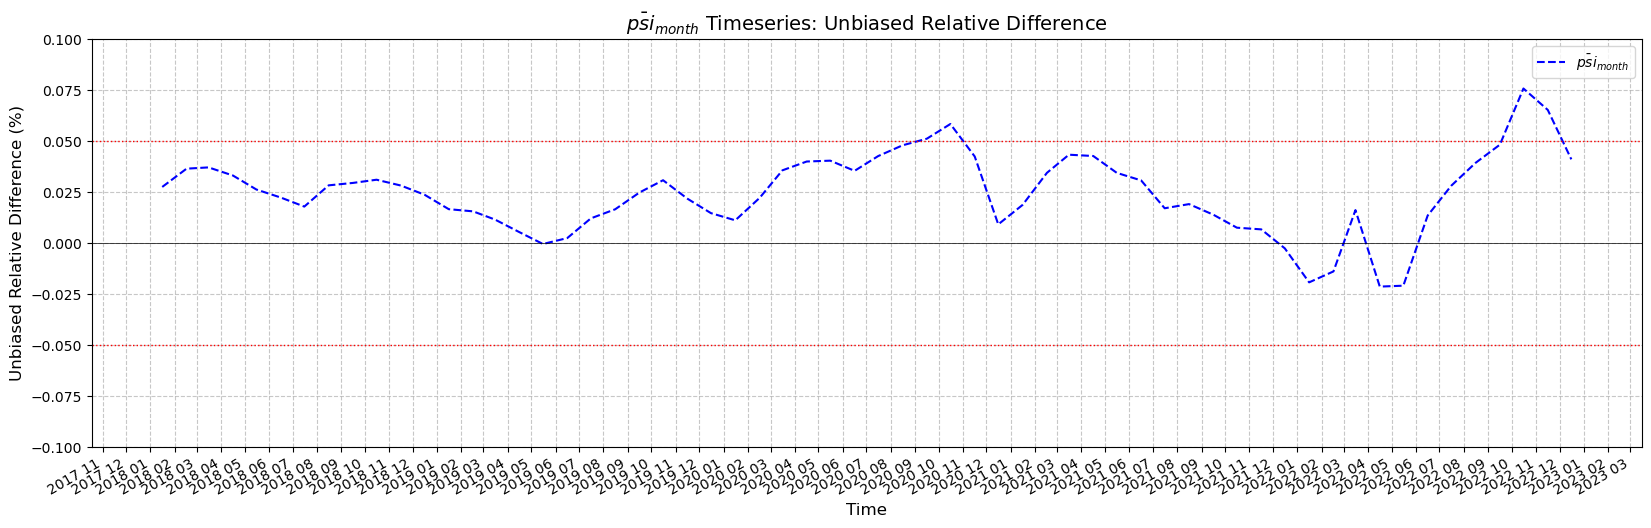

In [16]:
# Calculate monthly mean psi
psi_mean2 = da.mean(dim=["latitude", "longitude"], skipna=True)

# Adjust the time values to the 16th of each month
my_date = my_date.map(lambda x: x.replace(day=16))

# Plot the timeseries
plot_psi_timeseries(my_date, psi_mean2)

# Uncomment the last three lines to download the plot as a png
# output_file = "modis_noaa20_psi_timeseries.png"
# plt.savefig(output_file, dpi=300, bbox_inches="tight")
# print(f"Plot saved as {output_file}")

## Calculate and plot spatial variability of psi
### Function to plot the spatial variability

In [17]:
def plot_spatial_variability(ds, da):
    """
    Plots the spatial variability of the mean unbiased relative difference (psi)
    across latitude and longitude for a given time range.

    Args:
        ds (xarray.Dataset): The dataset containing longitude and latitude coordinates.
        da (xarray.Dataset): The data array containing psi values with a "time" dimension.

    Functionality:
        - Calculates the mean psi values across the "time" dimension.
        - Creates a 2D map of psi values, showing spatial variability across latitude and longitude.
        - Uses a color scale ranging from -0.25 to 0.25 to represent psi values.

    Plot Features:
        - The map is displayed as a pseudocolor plot.
        - A color bar is added to indicate the scale of psi values, labeled in percent.
        - The x-axis (longitude) and y-axis (latitude) are labeled appropriately.
        - Includes a title summarizing the plot.
        - Gridlines are added for reference.
    """
    psi_mean = da.mean(dim="time", skipna=True).values

    # Plot the spatial variability as a 2D Map
    plt.figure(figsize=(10, 6))

    # Use color with a range from -20% to 20%
    plt.pcolormesh(
        ds.longitude,
        ds.latitude,
        psi_mean,
        cmap="coolwarm",
        vmin=-0.25,
        vmax=0.25,
    )

    # Add a colorbar
    cbar = plt.colorbar()
    cbar.set_label(r"$\bar{\psi}_{lat/lon}$ (percent)")

    # Add labels and title
    plt.title(
        r"$\bar{\psi}_{lat/lon}$ Spatial Variability of 2018-2022 Mean",
        fontsize=14,
    )
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)

    # Add gridlines
    plt.grid(True, linestyle="--", alpha=0.7)

    plt.show()

### Plot the spatial variability

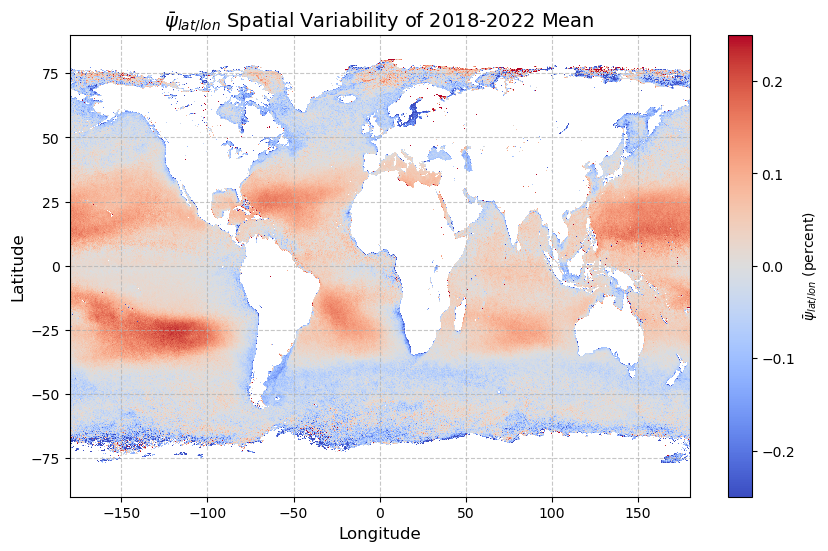

In [18]:
# Assign the centered time back to the dataset
da["time"] = my_date

# Calculate the mean psi values across the "time" dimension ignoring missing values (NaN)
psi_mean = da.mean(dim="time", skipna=True).values

# Plot the spatial variability
plot_spatial_variability(ds, da)

# Uncomment the last three lines to download the plot as a png
# output_file = "modis_noaa20_psi_spatial_variability.png"
# plt.savefig(output_file, dpi=300, bbox_inches="tight")
# print(f"Plot saved as {output_file}")